<a href="https://colab.research.google.com/github/Funmi-lois/Pizza-Sales-Analysis-/blob/main/Task_3_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [288]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pizza Sales Analysis
## Importing the Libraries

In [289]:
import pandas as pd

orders = pd.read_csv('orders.csv')
order_details = pd.read_csv('order_details.csv')
pizzas = pd.read_csv('pizzas.csv')
pizza_types = pd.read_csv('pizza_types.csv', encoding='latin1')

## Previewing the Datasets

In [290]:
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [291]:
order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [292]:
pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [293]:
pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


## Merging the Datasets

In [294]:

sales = pd.merge(order_details, orders, on='order_id')
sales = pd.merge(sales, pizzas, on='pizza_id')
sales = pd.merge(sales, pizza_types, on='pizza_type_id')

In [295]:
sales.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [296]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  object 
 5   time              48620 non-null  object 
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [297]:
sales.columns

Index(['order_details_id', 'order_id', 'pizza_id', 'quantity', 'date', 'time',
       'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients'],
      dtype='object')

# Pizza Place Sales Analysis

In [298]:
## Question 1: What is the total revenue/sales?

sales['total_sales'] = sales['quantity'] * sales['price']

total_revenue = sales['total_sales'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 817860.05


In [299]:
## Question 2: Find the total quantity sold

total_quantity = sales['quantity'].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 49574


In [300]:
## Question 3: Find the total orders
total_orders = sales['order_id'].nunique()

print("Total Orders:", total_orders)

Total Orders: 21350


In [301]:
## Question 4: How many pizza types do they sell?
pizza_types_count = sales['pizza_type_id'].nunique()

print("Number of Pizza Types:", pizza_types_count)

Number of Pizza Types: 32


In [302]:
## Question 5: Find the average price of the pizzas
average_price = sales['price'].mean()

print("Average Price:", round(average_price, 2))

Average Price: 16.49


Sales Dataframe contain a time column, extracting hour to count the the orders

In [303]:
## Question 6: What are the peak hours of sales?
sales['hour'] = pd.to_datetime(sales['time']).dt.hour

peak_hours = sales.groupby('hour')['order_id'].count().sort_values(ascending=False)

peak_hours

/tmp/ipykernel_1858/1588660521.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales['hour'] = pd.to_datetime(sales['time']).dt.hour


,order_id
hour,
12,6543
13,6203
18,5359
17,5143
19,4350
16,4185
14,3521
20,3487
15,3170


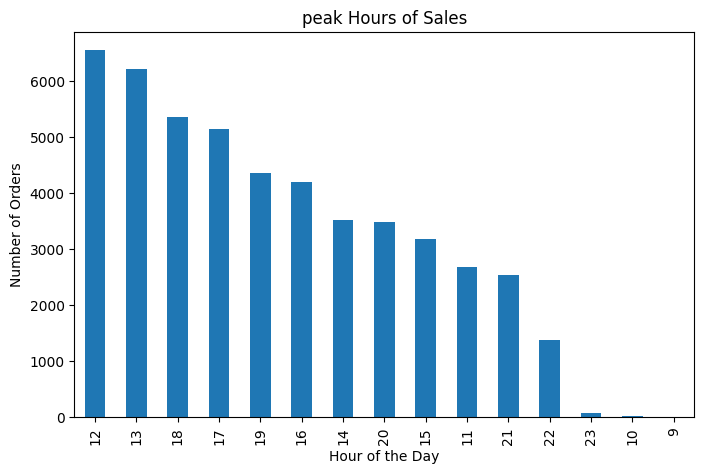

In [304]:
peak_hours.plot(kind='bar', figsize=(8,5))

plt.title('peak Hours of Sales')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.show()

Sales are highest during the hours with the largest number of orders. These are the peak business hours, indicating when customer demand is greatest.

In [305]:
##Question 7: Find the total sales made on each day of the week. Which day has the highest sales?
## Sales by Day of the Week

sales['date'] = pd.to_datetime(sales['date'])

sales['day_of_week'] = sales['date'].dt.day_name()

daily_sales = sales.groupby('day_of_week')['total_sales'].sum()

daily_sales

,total_sales
day_of_week,
Friday,136073.90
Monday,107329.55
Saturday,123182.40
Sunday,99203.50
Thursday,123528.50
Tuesday,114133.80
Wednesday,114408.40


To display the days in calendar order instead of alphabetical order:

In [306]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_sales = daily_sales.reindex(days)

daily_sales

,total_sales
day_of_week,
Monday,107329.55
Tuesday,114133.80
Wednesday,114408.40
Thursday,123528.50
Friday,136073.90
Saturday,123182.40
Sunday,99203.50


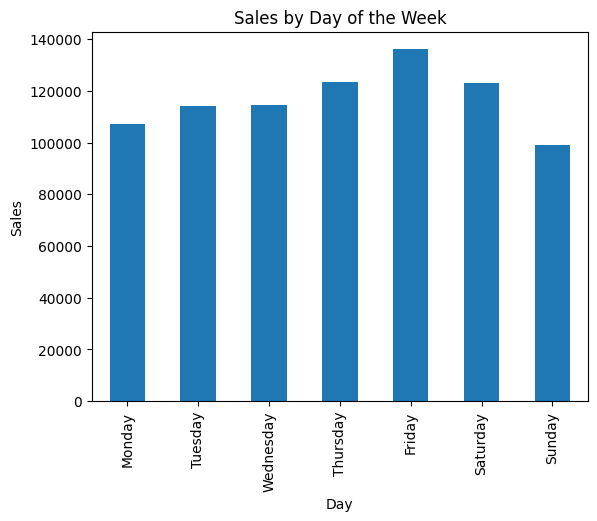

In [307]:
daily_sales.plot(kind='bar')

plt.title('Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.show()

In [308]:
## Question 8: Find the Top 5 Best-Selling Pizzas
top_5_pizzas = sales.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5)

top_5_pizzas

,quantity
name,
The Classic Deluxe Pizza,2453
The Barbecue Chicken Pizza,2432
The Hawaiian Pizza,2422
The Pepperoni Pizza,2418
The Thai Chicken Pizza,2371


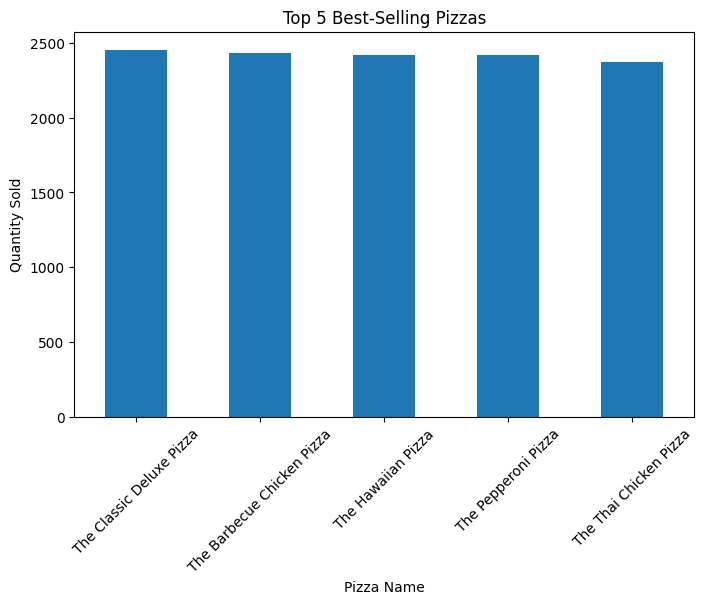

In [309]:
top_5_pizzas.plot(kind='bar', figsize=(8,5))

plt.title('Top 5 Best-Selling Pizzas')
plt.xlabel('Pizza Name')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

The chart shows the five pizzas with the highest quantity sold. These pizzas are the most popular among customers and contribute significantly to the business's sales.

In [310]:
## Question 9: Find the sales made in each month. Is there any noticeable trend?
## ensure it is in date time format
sales['date'] = pd.to_datetime(sales['date'])

In [311]:
## exact month name
sales['month'] = sales['date'].dt.month_name()

In [312]:
##Calculate monthly sales
monthly_sales = sales.groupby('month')['total_sales'].sum()
monthly_sales

,total_sales
month,
April,68736.80
August,68278.25
December,64701.15
February,65159.60
January,69793.30
July,72557.90
June,68230.20
March,70397.10
May,71402.75


In [313]:
##order of the months
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = monthly_sales.reindex(months)

monthly_sales

,total_sales
month,
January,69793.30
February,65159.60
March,70397.10
April,68736.80
May,71402.75
June,68230.20
July,72557.90
August,68278.25
September,64180.05


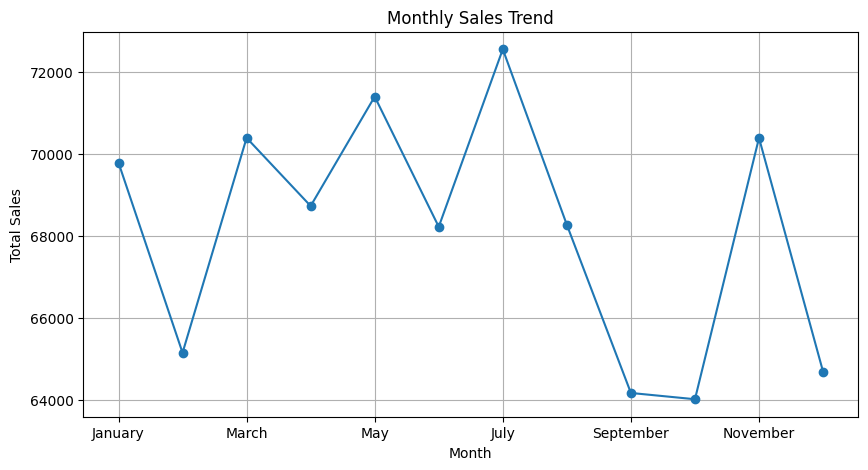

In [314]:
monthly_sales.plot(kind='line', marker='o', figsize=(10,5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Monthly sales vary throughout the year. Sales increased during some months and declined in others, indicating seasonal fluctuations in customer demand. The month with the highest sales was July, while October recorded the lowest sales.

In [315]:
## Question 10: Are there pizza types that are not doing well on the menu?
low_selling_pizzas = sales.groupby('name')['quantity'].sum().sort_values().head(10)

low_selling_pizzas

,quantity
name,
The Brie Carre Pizza,490
The Mediterranean Pizza,934
The Calabrese Pizza,937
The Spinach Supreme Pizza,950
The Soppressata Pizza,961
The Spinach Pesto Pizza,970
The Chicken Pesto Pizza,973
The Italian Vegetables Pizza,981
The Chicken Alfredo Pizza,987


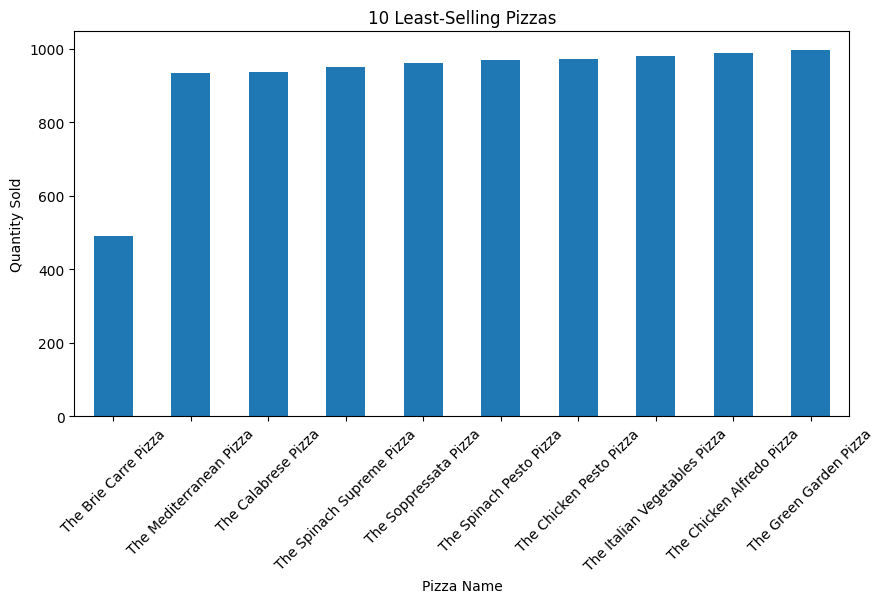

In [316]:

low_selling_pizzas.plot(kind='bar', figsize=(10,5))
plt.title('10 Least-Selling Pizzas')
plt.xlabel('Pizza Name')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

The pizzas with the lowest quantities sold are the least popular items on the menu. Management may consider promoting these pizzas, reviewing their pricing, or replacing them with more appealing options if low sales persist.

In [317]:
## Additional Analysis: Sales by Pizza Category
category_sales = sales.groupby('category')['total_sales'].sum().sort_values(ascending=False)
category_sales

,total_sales
category,
Classic,220053.10
Supreme,208197.00
Chicken,195919.50
Veggie,193690.45


This analysis shows which pizza category generated the highest revenue. The result can help the business focus on the most profitable categories while improving or promoting lower-performing ones.
Adding one or two extra analyses.
# Conclusion

This analysis explored a year's worth of pizza sales data. The results identified the total revenue, total quantity sold, total orders, number of pizza types, average pizza price, peak sales hours, daily and monthly sales trends, the top-selling pizzas, and the least-performing pizzas. These insights can help the business make informed decisions about inventory, staffing, promotions, and menu optimization.